https://pymoo.org/algorithms/moo/nsga2.html

In [1]:
!pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.4 MB/s eta 0:00:00


In [2]:
import pymoo.gradient.toolbox as anp
import numpy as np
import pandas as pd
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.visualization.scatter import Scatter
from pymoo.optimize import minimize

import matplotlib.pyplot as plt

import plotly.express as px

import tensorflow as tf
from tensorflow import keras
from keras.models import load_model
from pickle import load

In [3]:
class func(Problem):
    def __init__(self):
        super().__init__(n_var=2, n_obj=2, n_ieq_constr=2, vtype=float)
        self.xl = np.array([0.1, 0]) #lower limit
        self.xu = np.array([1.0, 5]) #upper limit 상한

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x[:, 0]
        f2 = (1 + x[:, 1]) / x[:, 0]

        g1 = 9 * x[:, 0] + x[:, 1] - 6 # const, >=0 제약함수 g=9x1+x2-6
        g2 = 9 * x[:, 0] - x[:, 1] - 1 # const, >=0

        out["F"] = anp.column_stack([f1, f2])

        out["G"] = anp.column_stack([g1, g2])
        out["G"] = - out["G"]

In [4]:
problem = func()

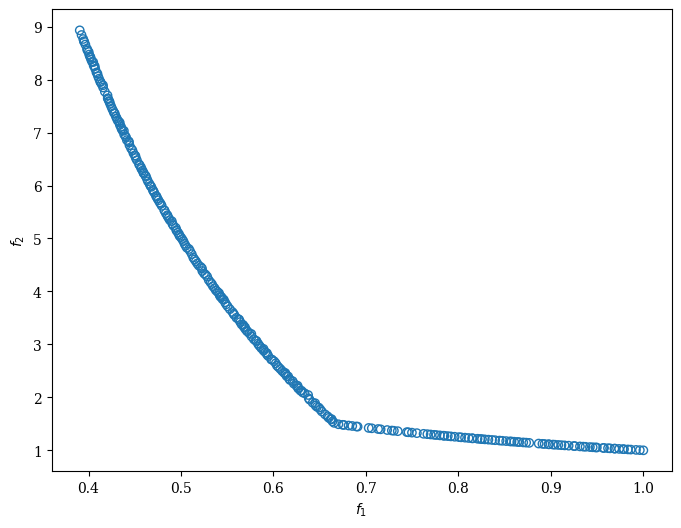

In [5]:
algorithm = NSGA2(pop_size=300)

res = minimize(problem,
               algorithm,
               ('n_gen', 200),
               seed=1,
               verbose=False)

plot = Scatter()
plot.add(res.F, facecolor="none")
plot.show()

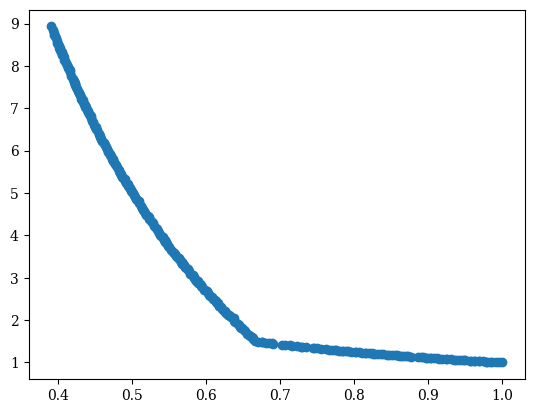

In [6]:
plt.scatter(res.F[:,0], res.F[:,1])
plt.show()

https://wikidocs.net/185748

In [7]:
fig = px.scatter(x=res.F[:, 0], y=res.F[:, 1], width=800, height=600)
fig.show()

In [8]:
x1 = np.linspace(0.1, 1.0, 400)
x2 = np.linspace(0, 5, 400)
X1, X2 = np.meshgrid(x1, x2)

g1 = 9*X1 + X2 - 6
g2 = 9*X1 - X2 - 1

feasible = (g1 >= 0) & (g2 >= 0)

samples = []
for _ in range(5000):
    x1_rand = np.random.uniform(0.1, 1.0)
    x2_rand = np.random.uniform(0.0, 5.0)
    if (9*x1_rand + x2_rand - 6 >= 0) and (9*x1_rand - x2_rand - 1 >= 0):
        samples.append([x1_rand, x2_rand])
samples = np.array(samples)

f1 = samples[:,0]
f2 = (1 + samples[:,1]) / samples[:,0]

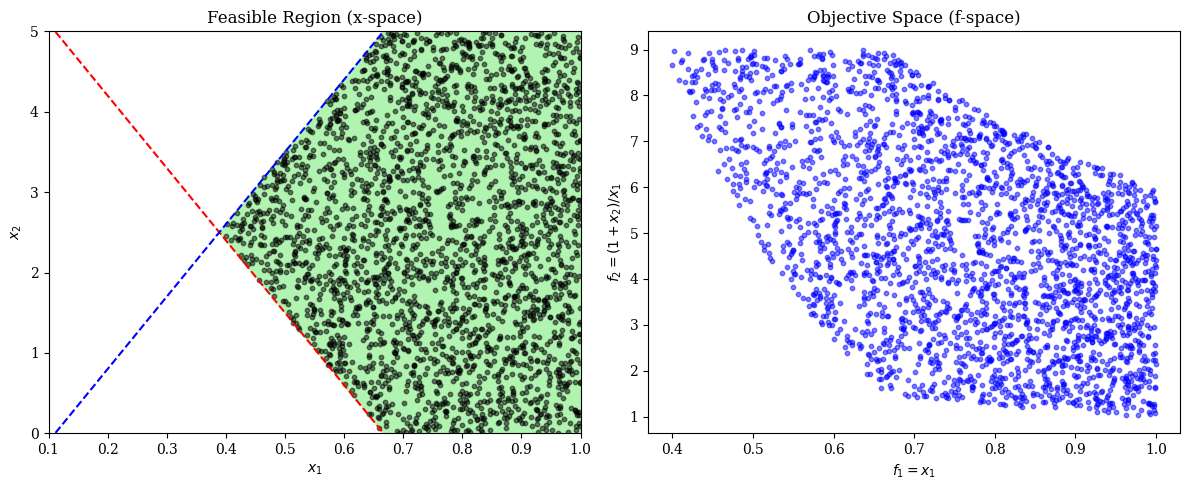

In [9]:
fig, axs = plt.subplots(1,2, figsize=(12,5))

axs[0].contourf(X1, X2, feasible, levels=[-0.5,0.5,1.5], colors=["white","lightgreen"], alpha=0.7)
axs[0].plot(x1, 6 - 9*x1, "r--")
axs[0].plot(x1, 9*x1 - 1, "b--")
axs[0].scatter(samples[:,0], samples[:,1], s=10, c="k", alpha=0.5)
axs[0].set_title("Feasible Region (x-space)") # 설계변수의 영역 (부등식의 영역)
axs[0].set_xlabel(r"$x_1$")
axs[0].set_ylabel(r"$x_2$")
axs[0].set_xlim(0.1,1.0)
axs[0].set_ylim(0,5)

axs[1].scatter(f1, f2, s=10, c="blue", alpha=0.5)
axs[1].set_title("Objective Space (f-space)") #최적함수의 영역
axs[1].set_xlabel(r"$f_1 = x_1$")
axs[1].set_ylabel(r"$f_2 = (1+x_2)/x_1$")

plt.tight_layout()
plt.show()


In [10]:
f_min = res.F.min(axis=0)
f_max = res.F.max(axis=0)
res_F_norm = (res.F - f_min) / (f_max - f_min)

In [11]:
ref_point = np.array([0, 0])
delta = np.abs(res_F_norm - ref_point)
distances = np.linalg.norm(delta, axis=1)
best_idx = np.argmin(distances)
best_point = res.F[best_idx]

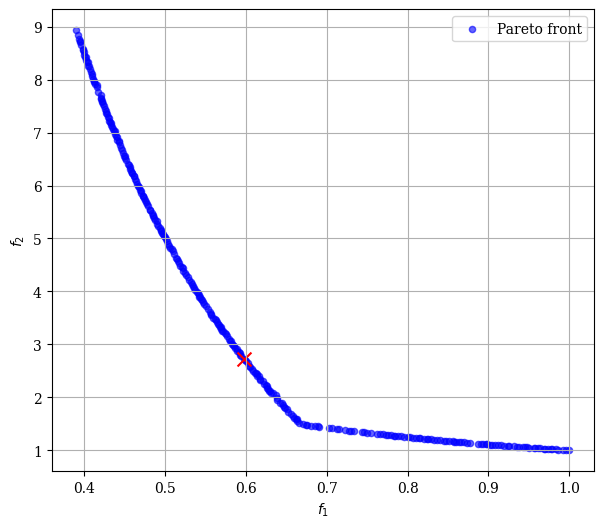

[0.59754697 2.71581919] 0.40276203265893484


In [12]:
plt.figure(figsize=(7,6))
plt.scatter(res.F[:,0], res.F[:,1], s=20, c="blue", alpha=0.6, label="Pareto front")
plt.scatter(best_point[0], best_point[1], s=100, c="red", marker="x")
plt.xlabel("$f_1$")
plt.ylabel("$f_2$")
plt.legend()
plt.grid(True)
plt.show()

print(best_point, distances[best_idx])
